In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def load_dataset():
    """
    Load the dataset from a text file.

    The dataset is expected to be in a text file named 'trainData.txt',
    where each line contains comma-separated values. The last value in each
    line is assumed to be the label.

    Returns:
    tuple: A tuple containing:
        - X (numpy.ndarray): The feature matrix with shape (n_samples, n_features).
        - y (numpy.ndarray): The labels array with shape (n_samples,).
    """
    with open('trainData.txt', 'r') as f:
        data = []
        for line in f:
            data.append(line.split(','))
        data = np.array(data)
        X = data[:, :-1].astype(float)
        y = data[:, -1].astype(int)
        return X, y

# Load the dataset
X, y = load_dataset()

[[ 1.85284048 -0.16436898  1.09839078 -0.93073689 -1.0193342   1.16696309]
 [-0.21530775  1.63665974 -0.61831145  0.99002204  0.38670252  1.15926273]
 [ 0.04653456 -1.16487257  0.04392191 -0.41369086 -1.08847926 -1.37988988]
 ...
 [-0.06393955 -0.92205024  1.65445602 -1.527528    1.87609599  0.75929015]
 [ 1.06665359  3.27717415 -0.53087884  1.42338924 -1.11381038 -0.15047129]
 [-0.47186462 -0.37118987 -1.04041218 -0.253746   -0.02120134 -1.4376229 ]]


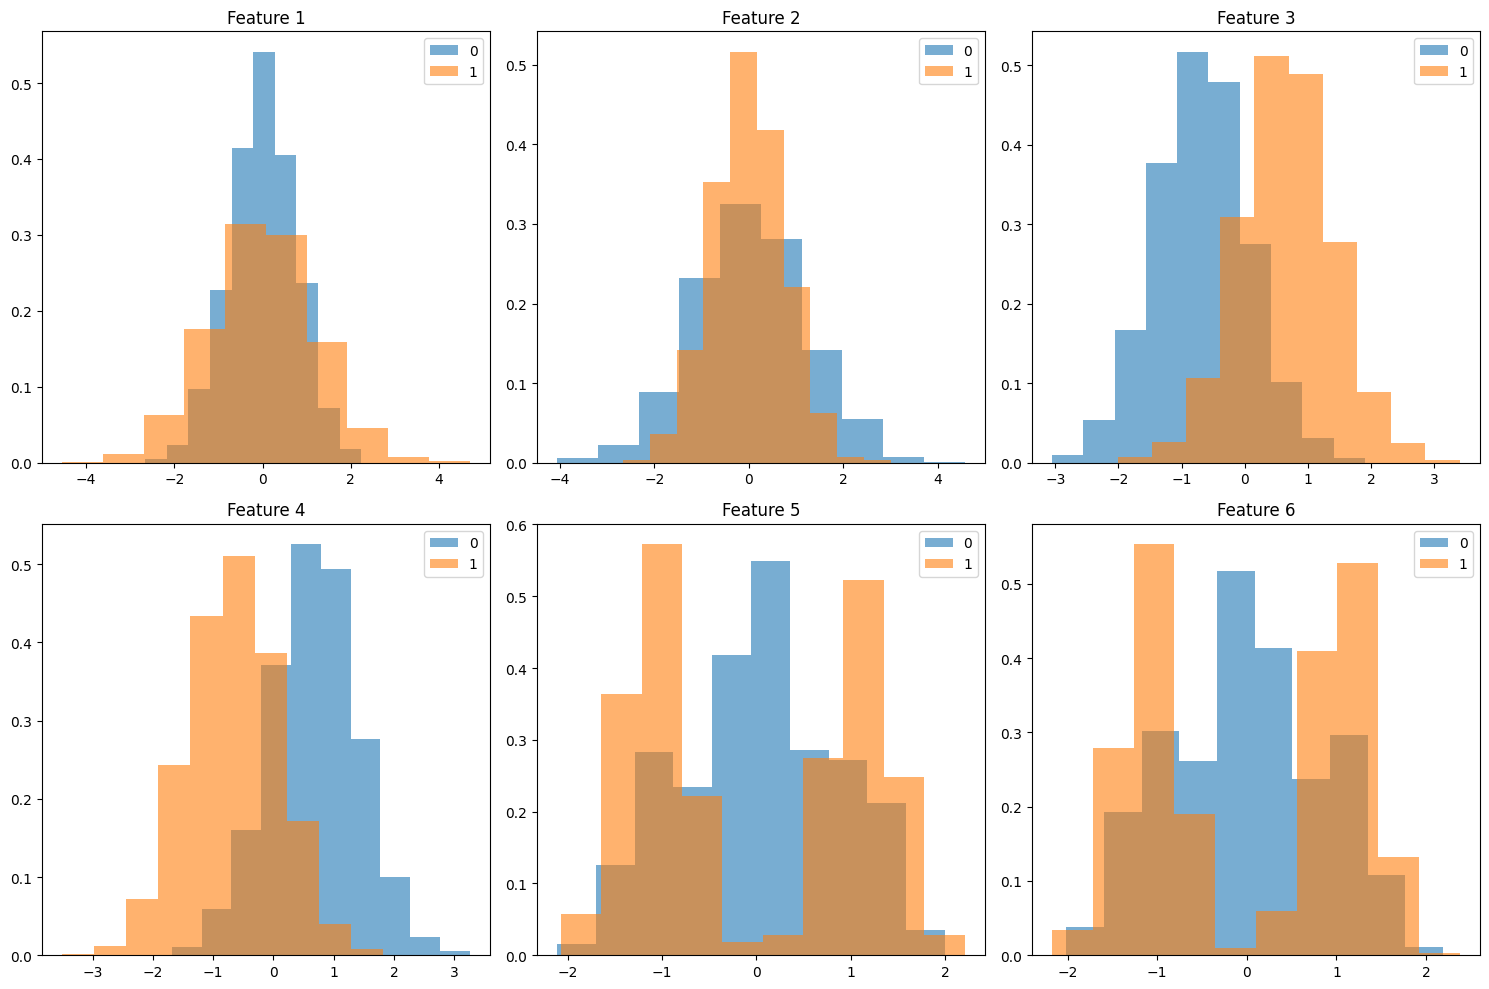

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def normalized_histogram(X, y):
    """
    Plot the normalized histogram of each feature per label.

    Parameters:
    X (numpy.ndarray): The feature matrix with shape (n_samples, n_features).
    y (numpy.ndarray): The labels array with shape (n_samples, n_features).

    Returns:
    None
    """
    unique_labels = np.unique(y)
    n_features = X.shape[1]
    n_rows = (n_features + 2) // 3  # Calculate the number of rows needed

    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i in range(n_features):
        for l in unique_labels:
            axes[i].hist(X[y == l, i], bins=10, alpha=0.6, density=True, label=l)
        axes[i].set_title(f'Feature {i+1}')
        axes[i].legend()

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Plot the normalized histogram of each feature per label
normalized_histogram(X, y)

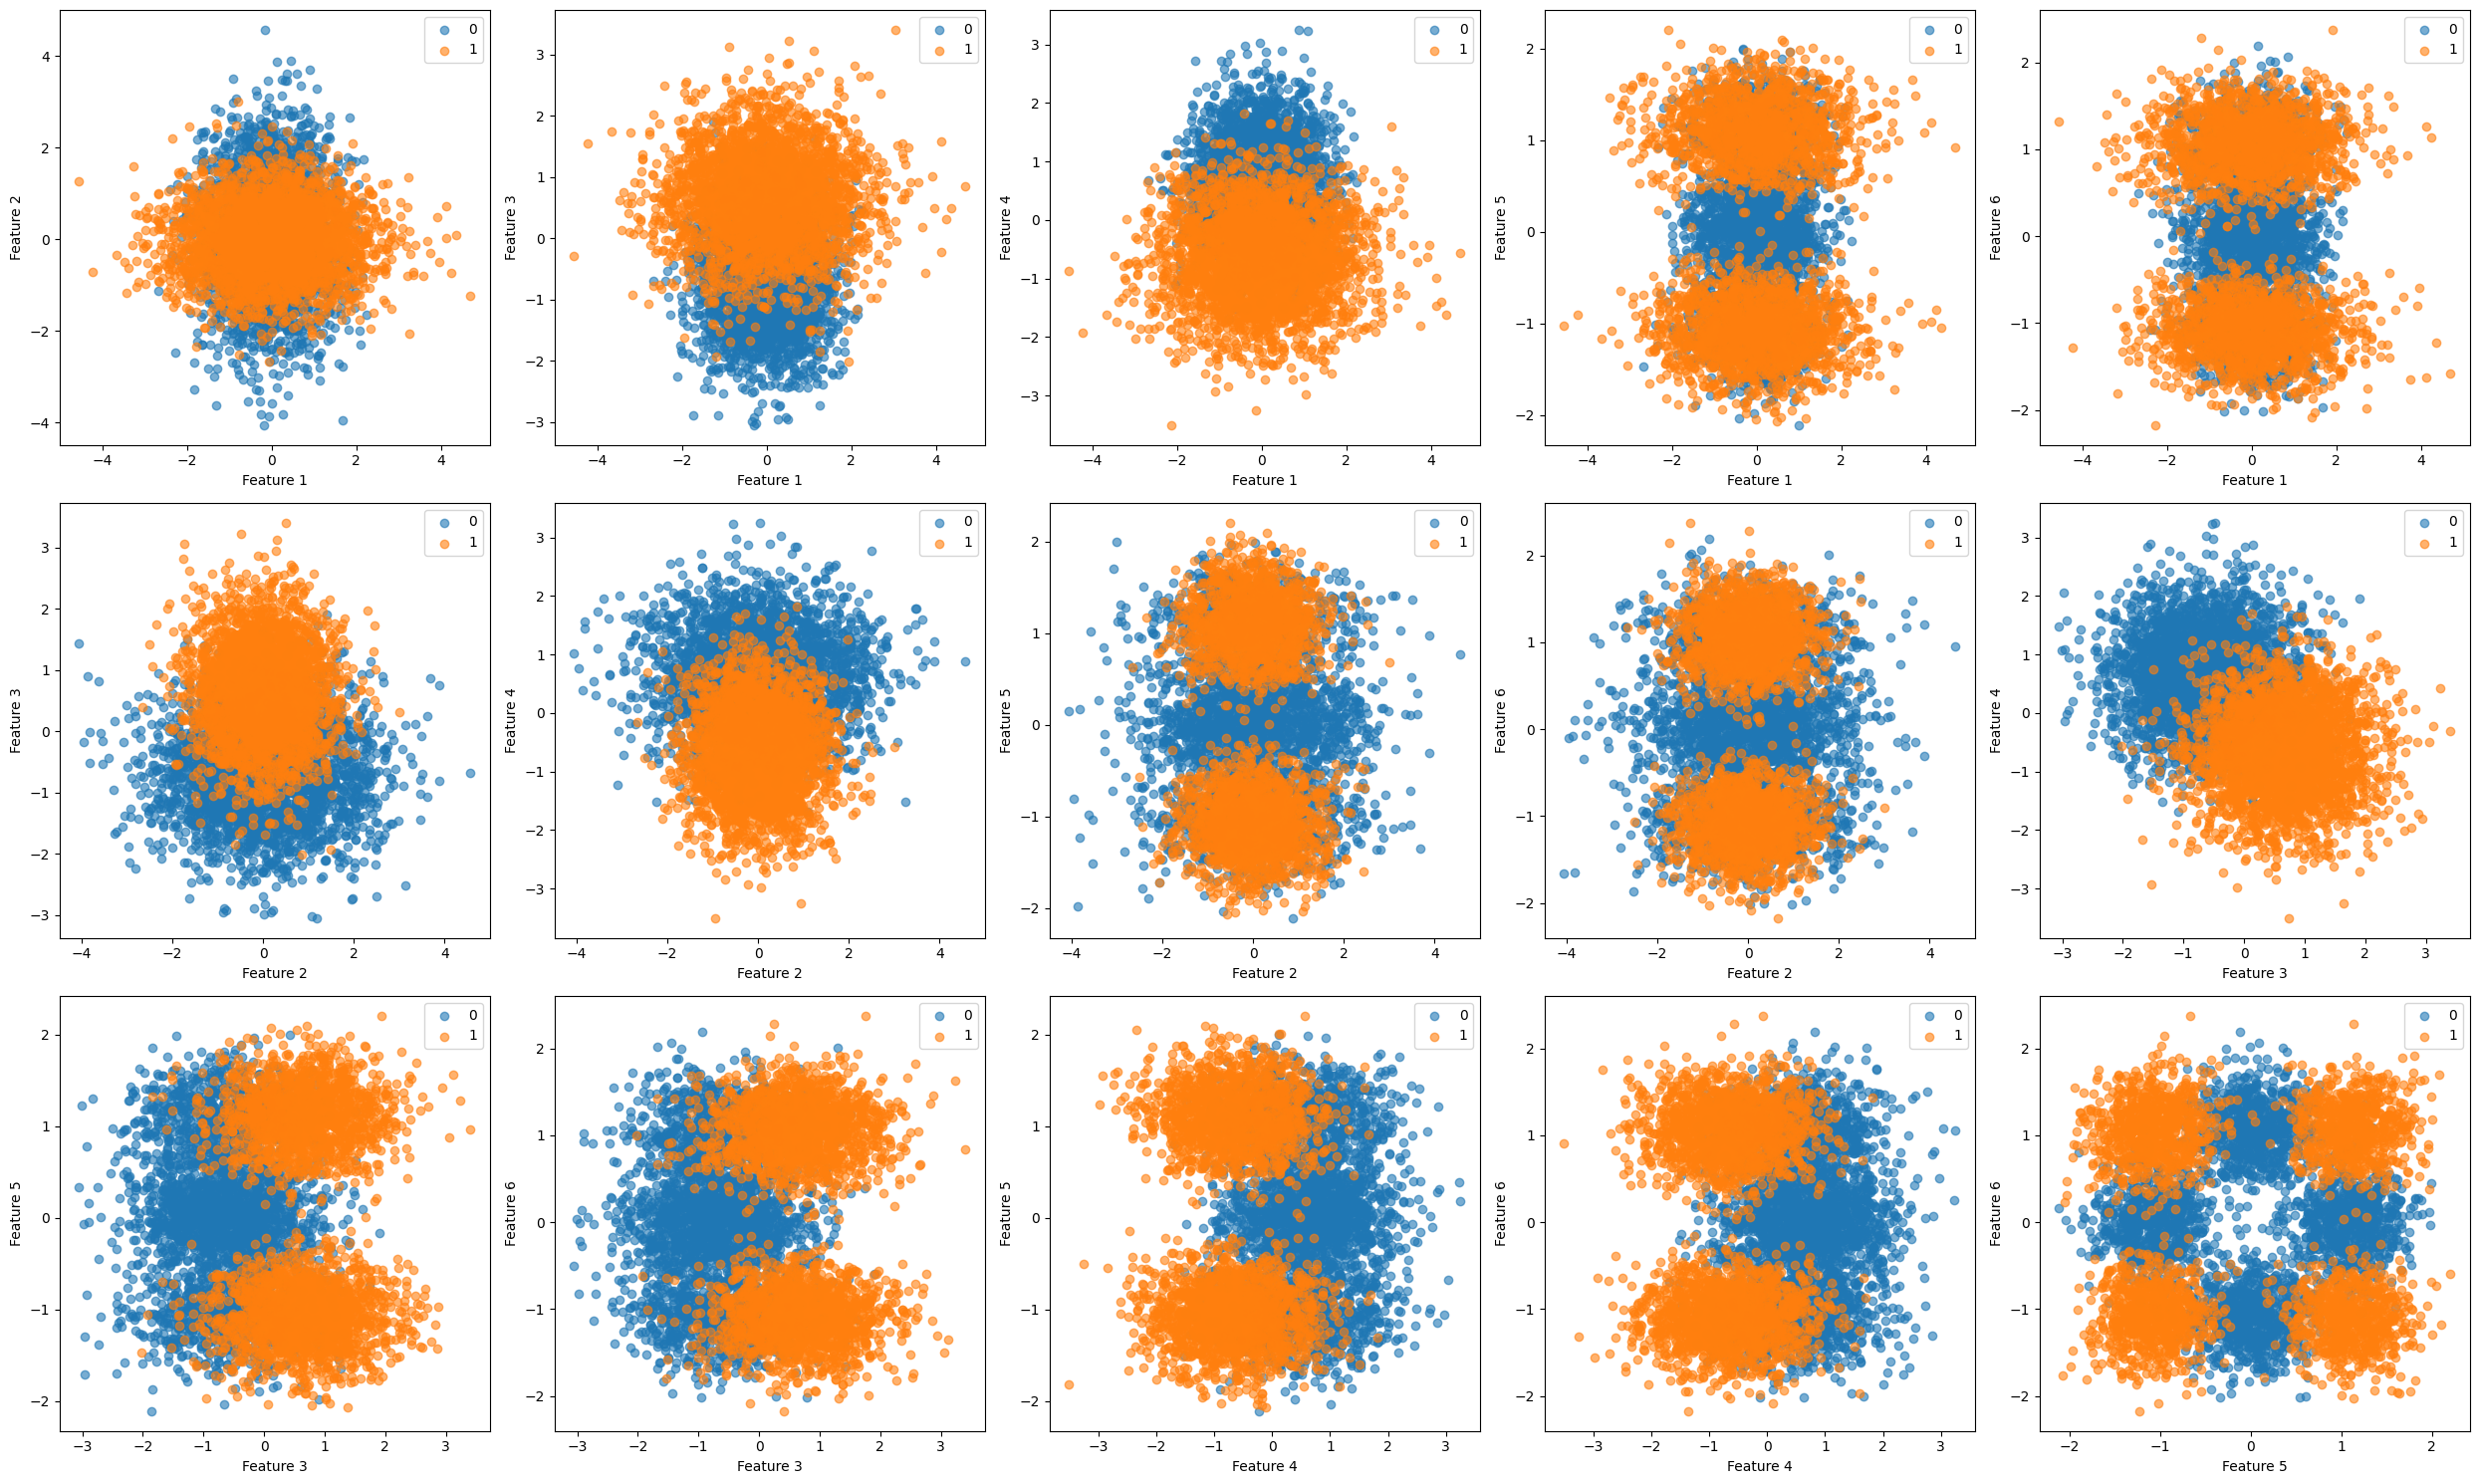

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def pair_wise_scatter(X, y):
    """
    Plot the pair-wise scatter plot of each feature pair.

    Parameters:
    X (numpy.ndarray): The feature matrix with shape (n_samples, n_features).
    y (numpy.ndarray): The labels array with shape (n_samples,).

    Returns:
    None
    """
    unique_labels = np.unique(y)
    n_features = X.shape[1]
    n_plots = n_features * (n_features - 1) // 2
    n_rows = (n_plots + 4) // 5  # Calculate the number of rows needed

    fig, axes = plt.subplots(n_rows, 5, figsize=(25, 5 * n_rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    plot_idx = 0
    for i in range(n_features):
        for j in range(i + 1, n_features):
            for l in unique_labels:
                axes[plot_idx].scatter(X[y == l, i], X[y == l, j], alpha=0.6, label=l)
            axes[plot_idx].set_xlabel(f'Feature {i+1}')
            axes[plot_idx].set_ylabel(f'Feature {j+1}')
            axes[plot_idx].legend()
            plot_idx += 1

    # Hide any unused subplots
    for k in range(plot_idx, len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

# Plot the pair-wise scatter plot of each feature pair
pair_wise_scatter(X, y)

In [21]:
def center_data(X):
    """
    Center the dataset by subtracting the mean of each feature.

    Parameters:
    X (numpy.ndarray): The feature matrix with shape (n_samples, n_features).

    Returns:
    numpy.ndarray: The centered feature matrix with the same shape as X.
    """
    mu = np.mean(X, axis=0).reshape(1, -1)
    return X - mu

# Center the dataset
Xc = center_data(X)

In [31]:
def covariance_matrix(Xc, y):
    """
    Compute the covariance matrix of the dataset.

    Parameters:
    Xc (numpy.ndarray): The centered feature matrix with shape (n_samples, n_features).
    y (numpy.ndarray): The labels array with shape (n_samples,).

    Returns:
    dict: A dictionary where keys are unique labels and values are the covariance matrices
          for each label with shape (n_features, n_features).
    """
    cov_matrices = {}
    unique_labels = np.unique(y)
    for l in unique_labels:
        Xc_class = Xc[y == l]
        cov_matrices[l] = (Xc_class.T @ Xc_class) / float(Xc_class.shape[0])
    return cov_matrices

# Compute the covariance matrix
cov = covariance_matrix(Xc, y)
for l in cov.keys():
    print(f"Covariance Matrix for Label {l}:\n{cov[l]}\n")

Covariance Matrix for Label 0:
[[ 0.56958242  0.00444999  0.00764133  0.01523176  0.01430818 -0.00142898]
 [ 0.00444999  1.42105215 -0.01397914 -0.00309857 -0.00209549 -0.00574482]
 [ 0.00764133 -0.01397914  1.00605119 -0.43909425 -0.03513293  0.02118884]
 [ 0.01523176 -0.00309857 -0.43909425  0.98459543  0.03048608  0.00597349]
 [ 0.01430818 -0.00209549 -0.03513293  0.03048608  0.6812956   0.01147816]
 [-0.00142898 -0.00574482  0.02118884  0.00597349  0.01147816  0.70526142]]

Covariance Matrix for Label 1:
[[ 1.43023481  0.00588036 -0.00406738  0.01382668  0.00573376 -0.02441266]
 [ 0.00588036  0.57846188 -0.01767935  0.00219961 -0.00591791  0.0040767 ]
 [-0.00406738 -0.01767935  0.99893612 -0.43504003 -0.01864215 -0.00840243]
 [ 0.01382668  0.00219961 -0.43504003  0.99595449  0.02021963  0.01054986]
 [ 0.00573376 -0.00591791 -0.01864215  0.02021963  1.31897374 -0.00965613]
 [-0.02441266  0.0040767  -0.00840243  0.01054986 -0.00965613  1.28724612]]



In [33]:
def var_std(Xc, y):
    """
    Compute the variance and standard deviation of each feature for each label.

    Parameters:
    Xc (numpy.ndarray): The centered feature matrix with shape (n_samples, n_features).
    y (numpy.ndarray): The labels array with shape (n_samples,).

    Returns:
    tuple: A tuple containing:
        - variances (dict): A dictionary where keys are unique labels and values are the variances
                            of each feature for each label.
        - std_devs (dict): A dictionary where keys are unique labels and values are the standard
                           deviations of each feature for each label.
    """
    unique_labels = np.unique(y)
    variances = {}
    std_devs = {}
    for l in unique_labels:
        Xc_class = Xc[y == l]
        variances[l] = np.var(Xc_class, axis=0)
        std_devs[l] = np.std(Xc_class, axis=0)
    return variances, std_devs

# Compute the variance and standard deviation of each feature
var, std = var_std(Xc, y)
for l in var.keys():
    print(f"Variance for Label {l}:\n{var[l]}\n")
    print(f"Standard Deviation for Label {l}:\n{std[l]}\n")

Variance for Label 0:
[0.56958105 1.42086571 0.54997702 0.53604266 0.6800736  0.70503844]

Standard Deviation for Label 0:
[0.75470594 1.19200072 0.74160436 0.73214934 0.82466575 0.83966567]

Variance for Label 1:
[1.43023345 0.57827792 0.5489026  0.55334275 1.31776792 1.28702609]

Standard Deviation for Label 1:
[1.19592368 0.76044587 0.74087962 0.74387012 1.14794073 1.13447172]



In [34]:
def classes_means(Xc, y):
    """
    Compute the mean of each feature for each class.

    Parameters:
    Xc (numpy.ndarray): The centered feature matrix with shape (n_samples, n_features).
    y (numpy.ndarray): The labels array with shape (n_samples,).

    Returns:
    dict: A dictionary where keys are unique labels and values are the means of each feature
          for each label.
    """
    unique_labels = np.unique(y)
    means = {}
    for l in unique_labels:
        means[l] = np.mean(Xc[y == l], axis=0)
    return means

# Compute the mean of each feature for each class
means = classes_means(Xc, y)
for l in means.keys():
    print(f"Mean for Label {l}:\n{means[l]}\n")

Mean for Label 0:
[ 0.00117034  0.01365413 -0.67533263  0.66974082  0.03495721 -0.01493255]

Mean for Label 1:
[-0.00116256 -0.0135634   0.67084537 -0.66529072 -0.03472494  0.01483333]

